In [1]:
# Import required libraries
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

from config.config import *
from src.models.model1 import BinaryClassificationModel
import src.utils as ut
from sklearn.metrics import accuracy_score, roc_auc_score
from src.databases import PersistenceDiagramDatabase
from persim import wasserstein, bottleneck, plot_diagrams, PersistenceImager

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Load train, test datasets
train_dataset = ut.SeismicDataset(data_path=Path("../data/processed/signals_train.hdf5"))
test_dataset = ut.SeismicDataset(data_path=Path("../data/processed/signals_test.hdf5"))

print(f"\n✓ Datasets loaded successfully")
print(f"  Train: {len(train_dataset)} signals")
print(f"  Test: {len(test_dataset)} signals")
print(f"\nSample (signal, label, magnitude): {train_dataset[0]}")


✓ Datasets loaded successfully
  Train: 135 signals
  Test: 36 signals

Sample (signal, label, magnitude): (array([-124.9554206 , -225.88744057, -196.81946055, ...,  295.16472371,
        834.23270373, 1175.30068375], shape=(3800,)), np.int64(1), np.float64(4.4))


In [3]:
# Split train dataset
X_train, y_train, mag_train = train_dataset[:30]
print(len(X_train), len(y_train), len(mag_train))

30 30 30


In [4]:
db = PersistenceDiagramDatabase(labels=[0, 1], dim=20, tau=5, maxdim=0, sample=None, alpha=0.1)

mags_noise = []
mags_earthquake = []

for ix, (x, y, m) in enumerate(zip(X_train, y_train, mag_train)):
    db.add_signal(x, y)
    if y == 0:
        mags_noise.append(m)
    else:
        mags_earthquake.append(m)
    if (ix + 1) % 10 == 0:
        print(f"  Processed {ix + 1}/{len(X_train)} signals", end="\r")

dgms_noise = db.get_diagrams(label=0, dim=0)
dgms_earthquake = db.get_diagrams(label=1, dim=0)

# Combine magnitudes and diagrams
mags = mags_noise + mags_earthquake
dgms = dgms_noise + dgms_earthquake

In [5]:
# Matrix distance computation
n = len(dgms)   
dist_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(i + 1, n):
        dist = wasserstein(dgms[i], dgms[j], matching=False)
        dist_matrix[i, j] = dist
        dist_matrix[j, i] = dist
    print(f"  Computed distances for diagram {i + 1}/{n}", end="\r")

print("\n✓ Distance matrix computed successfully")
# Statistics of the distance matrix
print(f"  Mean distance: {np.mean(dist_matrix):.4f}")
print(f"  Std distance: {np.std(dist_matrix):.4f}")
print(f"  Min distance: {np.min(dist_matrix):.4f}")
print(f"  Max distance: {np.max(dist_matrix):.4f}")
print(f"  Shape: {dist_matrix.shape}")

  Computed distances for diagram 30/30
✓ Distance matrix computed successfully
  Mean distance: 57317757.1616
  Std distance: 139977766.2216
  Min distance: 0.0000
  Max distance: 599076774.9402
  Shape: (30, 30)


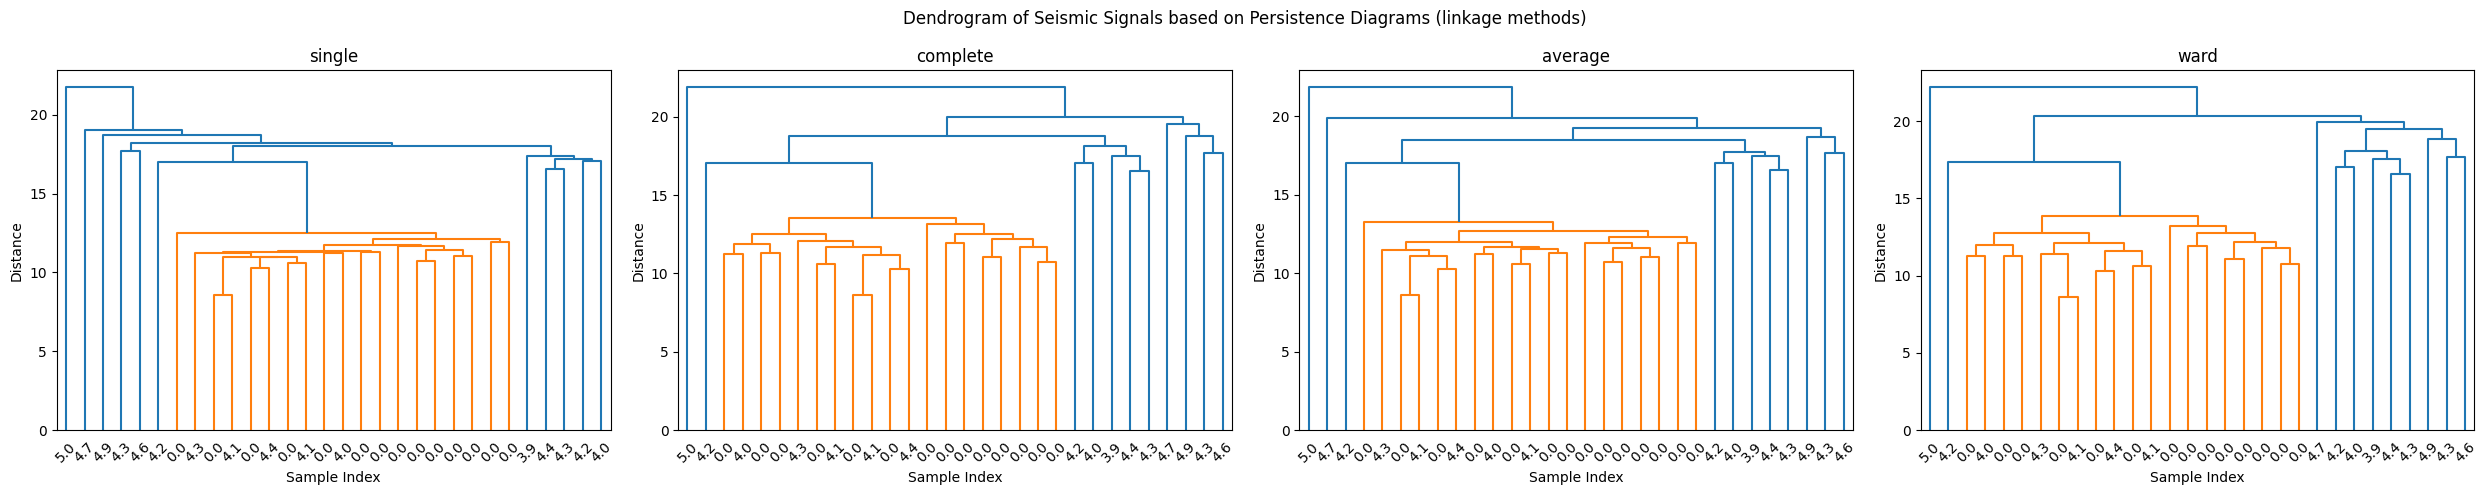

In [7]:
# Dendrogram plot
from scipy.cluster.hierarchy import dendrogram, linkage

plt.subplots(1, 4, figsize=(5*5, 5))
for i, method in enumerate(['single', 'complete', 'average', 'ward']):
    linked = linkage(dist_matrix, method=method)
    linked[:, 2] = np.log1p(linked[:, 2])  # only modify the distance column; log(1+x) for better visualization
    plt.subplot(1, 4, i+1)
    dendrogram(linked, labels=mags, show_leaf_counts=True)
    plt.title(f"{method}")
    plt.xlabel("Sample Index")
    plt.ylabel("Distance")
plt.suptitle(f"Dendrogram of Seismic Signals based on Persistence Diagrams (linkage methods)")
plt.tight_layout()
plt.show()